In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import numpy as np
import pandas as pd

In [3]:
import re
import string

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

In [5]:
#Negative data
fake_csv=pd.read_csv("hindi_fake.csv")
#positive data
true_csv=pd.read_csv("hindi_true.csv")

In [7]:
fake_csv.head()
#fetches top 5 data from the data set
#for negative label is 0

,text,label
0,इसके पहले एक तस्वीर वायरल है जो रोड पर 'गो बैक...,0
1,धातु के पहियों वाले ट्रैक्टर्स की पुरानी और अस...,0
2,सोशल मीडिया पर वायरल एक पोस्ट में दावा किया जा...,0
3,उत्तर प्रदेश (Uttar Pradesh) में आत्महत्या (su...,0
4,दिल्ली की सीमाओं पर केंद्र द्वारा लागू तीन कृष...,0


In [8]:
true_csv.head()
# fetches top 5 data from data set
#for positive label is 1

,text,label
0,सात सालों तक एक दूसरे से नहीं की बातआपको जानकर...,1
1,"ममता बनर्जी की फोटो शेयर कर बोले प्रकाश राज, \...",1
2,"असम: कांग्रेस पर साधा राजनाथ सिंह ने निशाना, क...",1
3,सरवणन को टिकट मिलने से नाराजगीरविवार सुबह तिरु...,1
4,दिल'धक-धक गर्ल माधुरी दीक्षित के साथ आमिर ने स...,1


In [9]:
true_csv.shape
#retuns the size of data set - being returns the number of rows and coloums

(5177, 2)

In [11]:
fake_csv.shape

(3481, 2)

In [12]:
#df=pd.concat([true_csv,fake_csv],axis=0)

In [13]:
# Determine the size of the smaller dataset
min_size = min(len(true_csv), len(fake_csv))

# Undersample the larger dataset to match the size of the smaller dataset
# do chezz hota hai oversampling - isme data set ka size badadete hai
#undersampling - undersampling me bigger data set ko reduce krte hai - hum ye kiye hai
df_true_undersampled = true_csv.sample(n=min_size, random_state=42)
df_fake_undersampled = fake_csv.sample(n=min_size, random_state=42)
#since eak me 5177 hai or dusre me 3000 hai then hum extrat krte time same records extract kre.. isiye random state fix krte hai ..
# aur jankari ke liye gpt kre ....
# random_state = 42 fixes the randomness.
# When sharing findings or training models, reproducibility ensures consistency in results.

# Concatenate the undersampled datasets
df = pd.concat([df_true_undersampled, df_fake_undersampled], ignore_index=True)
# ingnore_index = true ka matlab hai ki nayi DataFrame ka index 0 se shuru hoke sequential hoga, purane indexes ko ignore karega.

# Shuffle the concatenated dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
# The combined dataset df is shuffled to randomize the order of rows.
# frac=1 ensures that all rows are included in the shuffle.
# random_state=42 ensures reproducibility of the shuffle.
# reset_index(drop=True) resets the indices after shuffling and drops the old indices.


# Now df_equal_size contains both datasets of equal size

In [14]:
df.head()

,text,label
0,कोरोना महामारी के बीच यूपी की योगी आद‍ित्‍यनाथ...,1
1,अर्नब गोस्वामी के नेतृत्व वाले रिपब्लिक टीवी क...,0
2,इन दिनों लोकप्रिय डिटर्जेंट ब्रांड सर्फ एक्सेल...,0
3,"तमिलनाडु: चुनावों से पहले AIADMK को बड़ा झटका,...",1
4,वीडियो को अपलोड करके लोग दावा कर रहे हैं कि हा...,0


In [15]:
df.tail()

,text,label
6957,जून 29 को भारत सरकार ने 59 मोबाइल एप्प्स पर बै...,0
6958,मुस्लिमों तुम्हें खुदा का वास्ता...वोट मोदीजी ...,0
6959,ANI ने मोदी के रकाबगंज गुरुद्वारे जाने का एक व...,0
6960,चाहे वो चुनाव लड़ना हो या फिर राजनीतिक पार्टिय...,0
6961,इफोंसिस ने टॉप लेवल कर्मचारियों की संख्या को घ...,1


In [16]:
duplicate_rows = df[df.duplicated()]
print(duplicate_rows)
# is data set me duplicacy nai hai....
df = pd.concat([true_csv, fake_csv], axis=0).drop_duplicates()
#Tumhara df ab true_csv aur fake_csv ka combined version hai, jisme koi duplicate rows nahi hain. 😄
#Yeh check karta hai ki DataFrame df mein kaunsi rows duplicate (do baar ya usse zyada bar aayi hui) hain.

Empty DataFrame
Columns: [text, label]
Index: []


In [17]:
# A pandas DataFrame is like a table of data, similar to a spreadsheet or an Excel file.
# It's a very powerful tool in Python for organizing, analyzing, and manipulating data. Think of it as a grid where:

# Rows: Represent individual records or entries.
# Columns: Represent different types of information about those entries.
# Key Features:
# Labeled Rows and Columns:

# Rows are labeled with an index (numbers by default).
# Columns have names (you can set them).
# Handles Different Types of Data:

# Each column can have a different type of data (numbers, text, dates, etc.).

# df.isnull():

# This creates a DataFrame of the same shape as df, where each cell contains:
# True if the value is missing (NaN).
# False if the value is not missing.

df.isnull().sum()
# Bas, ab tumhe pata chal gaya ki DataFrame mein kahaan-kahaan missing data hai!
# Har column ke True values ko add kar deta hai (True = 1, False = 0).
# Bas, ab tumhe pata chal gaya ki DataFrame mein kahaan-kahaan missing data hai!



text     0
label    0
dtype: int64

In [18]:
df = df.sample(frac = 1)
# frac=1 ka matlab hai ki pura DataFrame (100% rows) shuffle hoga

In [19]:
(df['label'] == 0).sum()

np.int64(3481)

In [20]:
df

,text,label
4693,भारतीय जनता पार्टी (BJP) संसदीय दल की बैठक कल ...,1
3356,"क्या 31 दिसबंर से बैन हो जाएंगे 2 हजार के नोट,...",0
3473,"पहाड़ों पर जल सैलाब, सब कुछ तबाह....2013 जैसी ...",1
2004,दीपिका पादुकोण की मैनेजर करिश्मा प्रकाश के घर ...,1
2188,नई दिल्ली/लखनऊ.\nबलिया गोलीकांड केस में पुलिस ...,1
...,...,...
831,सोशल मीडिया पर फ़ैल रहे वीडिओज़ अक्सर झूठे दावे ...,0
4533,दिल्ली-देहरादून शताब्दी एक्सप्रेस के एक कोच मे...,1
4953,नेपाल की राजनीतिक परिस्थितियां इस समय अच्छी नह...,1
1051,संयुक्‍त राष्‍ट्र सुरक्षा परिषद में आज फहराया ...,1


In [21]:
#  wordopt is designed to clean and preprocess text by removing unwanted elements like special characters,
#  URLs, HTML tags, punctuation, and numbers
def wordopt(text):
    # text = text.lower()
    # Remove Text in Square Brackets:
    text = re.sub('\[.*?\]', '', text)
    text = re.sub("\\W"," ",text)
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)
    return text

In [22]:
# df_equal_size['text'] = df_equal_size['text'].apply(wordopt)
df['text'] = df['text'].apply(wordopt)


In [23]:
X = df['text']
y= df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Yeh line dataset ko train aur test sets mein split kar rahi hai
# Dataset ka 20% test set ke liye aur 80% train set ke liye rakha gaya hai.
# train_test_split() function sklearn library se aata hai aur dataset ko randomly train aur test parts mein todta hai.
# Ab tumhare paas alag-alag data hai training aur testing ke liye. 🎯
# X = df_equal_size['text']
# y= df_equal_size['label']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
# Bhai, yeh code tumhare text data ko TF-IDF
#(Term Frequency-Inverse Document Frequency) ke vectors mein convert kar raha hai
# dekh bhai kya ho raha h na ki ki tfidf jo h woh text ko vector me convert kar deta h taki importance patha kar sake har text ki .. se
# "The cat sat on the mat."
# "The dog sat on the log."
# "The cat played with the dog."
# toh aab patha karna hoga na ki khon sa word ka importnace jadha h ,..toh interger me convert karna hoga tf-idf does that .. more frequest word like the, is, on get less
#tf-idf score since thier signifance is less ..so first ['cat', 'sat', 'on', 'mat', 'dog', 'log', 'played', 'with', 'the'] then
# WORD EMBEDDING
tfidf_vectorizer = TfidfVectorizer()
# ye line bus initialize kar di h tfidf ko
# tfidf_matrix = tfidf_vectorizer.fit_transform(df['text'])
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
# aab fit_tranform training data  ka tf-idf score nikal lega
# fit: TF-IDF model ko train karta hai X_train data ke basis pe (matlab vocabulary aur weights samajhta hai).
X_test_tfidf = tfidf_vectorizer.transform(X_test)
# aab ye transform bhi same kaam karega that is tfidf score hi nikalega matrix form me but here difference is ko test data ka hoga and ushi word ka nikalega jo trainign data me hoga
#The cat jumped":
# Document	cat	sat	on	mat	dog	log	played	with	the
# "The cat jumped."	0.7	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0   .. jumped nahi h training data me toh yaha bhi nahi h .. see jumped ka score hi calcuate hi nahi hua h
# Output: Sparse matrix form mein vectors save hoti hain (memory-efficient representation).
# transform: X_train ko TF-IDF vectors mein convert karta hai.

In [25]:
# Convert sparse matrices to dense arrays
X_train_dense = X_train_tfidf.toarray()
X_test_dense = X_test_tfidf.toarray()
# Sparse matrix ko dense array mein convert karta hai (Numpy array form)
# sparse matix - memory eff hota hai ..
# dense matrix islye chahiye kyuki ml algo dense favor krta hai
# sparcse matrix ko samjna muskil hota hai


In [26]:
input_dim=X_train_dense.shape[0]
print(X_train_dense[1])
print(input_dim)

# X_train_dense.shape()
#It gives the dimensions of the array as a tuple: (number_of_rows, number_of_columns)
# Document	cat	sat	on	mat	dog	log	played	with	the
# "The cat sat on the mat."	0.4	0.4	0.4	0.5	0.0	0.0	0.0	0.0	0.0
# "The dog sat on the log."	0.0	0.4	0.4	0.0	0.4	0.5	0.0	0.0	0.0
# "The cat played with the dog."	0.3	0.0	0.0	0.0	0.3	0.0	0.4	0.4	0.0
# so we can see ki 6926 jo h woh total no of statement h .. like  the cat sat ..the dog sat ..sara add karke and 181119 jo columnn aaya tha woh total no of column h

[0. 0. 0. ... 0. 0. 0.]
6926


In [27]:
X_train_tensor = torch.tensor(X_train_dense, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1) # [N, 1] shape
X_test_tensor = torch.tensor(X_test_dense, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1) # [N, 1] shape

# Create PyTorch Dataset and DataLoader
BATCH_SIZE = 32
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Get input dimension (number of features/words)
input_dim = X_train_dense.shape[1]

In [28]:
# --- 2. DEFINE THE PYTORCH MODEL ---
# The Keras sequence: Embedding -> Flatten -> Dense -> Output

class SimpleANN(nn.Module):
    def __init__(self, input_dim):
        super(SimpleANN, self).__init__()
        # In Keras with TF-IDF, the Embedding layer essentially maps the sparse
        # vocabulary size to the embedding dimension. Since the input is already dense,
        # we treat this as a standard Feedforward network. The Flatten layer is implicit
        # because the input is already 2D (batch_size, features).
        
        # We start with the first Dense layer (units=128)
        self.fc1 = nn.Linear(input_dim, 128)
        self.relu = nn.ReLU()
        
        # Output layer (units=1, sigmoid activation)
        self.fc2 = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x is (batch_size, input_dim)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

In [33]:
# --- 3. INITIALIZE AND TRAIN ---

# Detect GPU and move model/data there
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}") # This will likely print "cpu" until CUDA/cuDNN is fixed

model = SimpleANN(input_dim).to(device)
criterion = nn.BCELoss() # Binary Cross-Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
N_EPOCHS = 30
for epoch in range(N_EPOCHS):
    model.train()
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    # Simple validation check (optional, but good practice)
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            val_loss += criterion(outputs, labels).item()

    print(f'Epoch {epoch+1}/{N_EPOCHS}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss/len(test_loader):.4f}')

Using device: cuda:0
Epoch 1/30, Train Loss: 0.1984, Val Loss: 0.1460
Epoch 2/30, Train Loss: 0.0101, Val Loss: 0.1029
Epoch 3/30, Train Loss: 0.0556, Val Loss: 0.0927
Epoch 4/30, Train Loss: 0.0388, Val Loss: 0.0913
Epoch 5/30, Train Loss: 0.0113, Val Loss: 0.0931
Epoch 6/30, Train Loss: 0.0156, Val Loss: 0.0960
Epoch 7/30, Train Loss: 0.0314, Val Loss: 0.1012
Epoch 8/30, Train Loss: 0.0349, Val Loss: 0.1038
Epoch 9/30, Train Loss: 0.0068, Val Loss: 0.1129
Epoch 10/30, Train Loss: 0.0051, Val Loss: 0.1135
Epoch 11/30, Train Loss: 0.0057, Val Loss: 0.1176
Epoch 12/30, Train Loss: 0.0003, Val Loss: 0.1288
Epoch 13/30, Train Loss: 0.0001, Val Loss: 0.1326
Epoch 14/30, Train Loss: 0.0015, Val Loss: 0.1331
Epoch 15/30, Train Loss: 0.0019, Val Loss: 0.1379
Epoch 16/30, Train Loss: 0.0002, Val Loss: 0.1467
Epoch 17/30, Train Loss: 0.0007, Val Loss: 0.1470
Epoch 18/30, Train Loss: 0.0008, Val Loss: 0.1546
Epoch 19/30, Train Loss: 0.0011, Val Loss: 0.1566
Epoch 20/30, Train Loss: 0.0009, Val L

In [35]:
# --- 4. EVALUATE AND CONFUSION MATRIX ---

# Evaluation
model.eval()
all_labels = []
all_preds = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        predictions = (outputs > 0.5).int()
        
        all_labels.extend(labels.squeeze().tolist())
        all_preds.extend(predictions.squeeze().tolist())

# Calculate Accuracy (similar to your Keras evaluation)
accuracy = np.mean(np.array(all_labels) == np.array(all_preds))
print(f'\nTest Accuracy: {accuracy:.4f}')


Test Accuracy: 0.9521


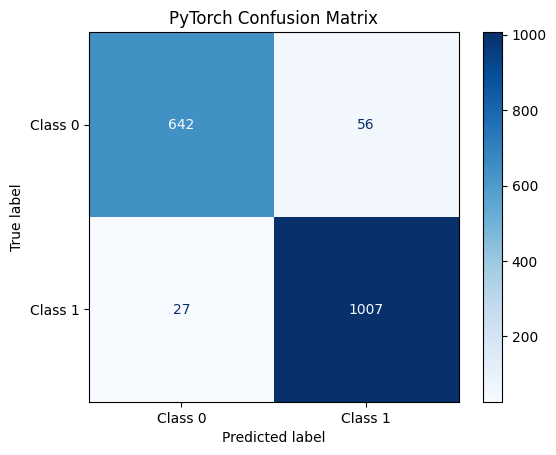

In [36]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap=plt.cm.Blues)
plt.title("PyTorch Confusion Matrix")
plt.show()

In [37]:
import torch
import pickle

# 1. Save the PyTorch Model State
# We save the 'state_dict' (weights) so we can load them later
torch.save(model.state_dict(), 'sentiment_model.pth')

# 2. Save the TF-IDF Vectorizer
# This is CRITICAL. We need the exact same vocabulary mapping for new user input.
# Assuming 'tfidf_vectorizer' is the name of your vectorizer variable from the notebook
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

print("Model and Vectorizer saved successfully!")

Model and Vectorizer saved successfully!
